In [1]:
from sklearn.model_selection import train_test_split
import pandas as pd
from sklearn.linear_model import LinearRegression, Lasso
from sklearn.tree import DecisionTreeRegressor
from sklearn.ensemble import RandomForestRegressor
from sklearn.model_selection import GridSearchCV, ShuffleSplit, cross_val_score
import matplotlib.pyplot as plt
import seaborn as sns
import numpy as np

In [2]:
df = pd.read_csv("Price_data.csv")
df.head()

,Unnamed: 0,property_type,price,location,city,baths,purpose,bedrooms,Area_in_Marla
0,0,Flat,10000000,G-10,Islamabad,2,For Sale,2,4.0
1,1,Flat,6900000,E-11,Islamabad,3,For Sale,3,5.6
2,2,House,16500000,G-15,Islamabad,6,For Sale,5,8.0
3,3,House,43500000,Bani Gala,Islamabad,4,For Sale,4,40.0
4,4,House,7000000,DHA Defence,Islamabad,3,For Sale,3,8.0


In [3]:
df.shape

(99499, 9)

In [4]:
df_1 = df[df.property_type == "House"].drop(columns=["purpose", "Unnamed: 0"])
df_1

,property_type,price,location,city,baths,bedrooms,Area_in_Marla
2,House,16500000,G-15,Islamabad,6,5,8.0
3,House,43500000,Bani Gala,Islamabad,4,4,40.0
4,House,7000000,DHA Defence,Islamabad,3,3,8.0
11,House,19000000,DHA Defence,Islamabad,3,3,10.0
12,House,26900000,B-17,Islamabad,6,6,20.0
...,...,...,...,...,...,...,...
99492,House,14000000,Bahria Town Karachi,Karachi,5,4,14.0
99495,House,8800000,Bahria Town Karachi,Karachi,4,3,8.0
99496,House,14000000,Bahria Town Karachi,Karachi,3,3,8.0
99497,House,14000000,Bahria Town Karachi,Karachi,4,4,14.0


In [5]:
df_1.isnull().sum()

property_type    0
price            0
location         0
city             0
baths            0
bedrooms         0
Area_in_Marla    0
dtype: int64

# Convert Units: 
Create new column Area_Sqrt_Feet from Area_in_Marla for better understanding. 1 Marla = 272.251 Sqaure_feet

In [6]:
df_1["Area_Sqrt_Feet"] = df_1["Area_in_Marla"].apply(lambda x: x*272.251)
df_1.head()

,property_type,price,location,city,baths,bedrooms,Area_in_Marla,Area_Sqrt_Feet
2,House,16500000,G-15,Islamabad,6,5,8.0,2178.008
3,House,43500000,Bani Gala,Islamabad,4,4,40.0,10890.040
4,House,7000000,DHA Defence,Islamabad,3,3,8.0,2178.008
11,House,19000000,DHA Defence,Islamabad,3,3,10.0,2722.510
12,House,26900000,B-17,Islamabad,6,6,20.0,5445.020


In [7]:
df_2 = df_1.copy().reset_index()
# df_2.drop("index")
df_2 = df_2.drop(columns=["index"])
df_2.head()

,property_type,price,location,city,baths,bedrooms,Area_in_Marla,Area_Sqrt_Feet
0,House,16500000,G-15,Islamabad,6,5,8.0,2178.008
1,House,43500000,Bani Gala,Islamabad,4,4,40.0,10890.040
2,House,7000000,DHA Defence,Islamabad,3,3,8.0,2178.008
3,House,19000000,DHA Defence,Islamabad,3,3,10.0,2722.510
4,House,26900000,B-17,Islamabad,6,6,20.0,5445.020


In [8]:
df_3 = df_2.copy()
df_3 = df_3.drop(columns=["property_type", "Area_in_Marla"])
df_3.head()

,price,location,city,baths,bedrooms,Area_Sqrt_Feet
0,16500000,G-15,Islamabad,6,5,2178.008
1,43500000,Bani Gala,Islamabad,4,4,10890.040
2,7000000,DHA Defence,Islamabad,3,3,2178.008
3,19000000,DHA Defence,Islamabad,3,3,2722.510
4,26900000,B-17,Islamabad,6,6,5445.020


In [9]:
df_4 = df_3.copy()
df_4 = df_4[["city", "location", "Area_Sqrt_Feet", "baths", "bedrooms", "price"]]
df_4

,city,location,Area_Sqrt_Feet,baths,bedrooms,price
0,Islamabad,G-15,2178.0080,6,5,16500000
1,Islamabad,Bani Gala,10890.0400,4,4,43500000
2,Islamabad,DHA Defence,2178.0080,3,3,7000000
3,Islamabad,DHA Defence,2722.5100,3,3,19000000
4,Islamabad,B-17,5445.0200,6,6,26900000
...,...,...,...,...,...,...
58164,Karachi,Bahria Town Karachi,3811.5140,5,4,14000000
58165,Karachi,Bahria Town Karachi,2178.0080,4,3,8800000
58166,Karachi,Bahria Town Karachi,2178.0080,3,3,14000000
58167,Karachi,Bahria Town Karachi,3811.5140,4,4,14000000


In [10]:
df_4["Price_per_Square_Feet"] = df_4["price"] / df_4["Area_Sqrt_Feet"]
df_4.head(15)

,city,location,Area_Sqrt_Feet,baths,bedrooms,price,Price_per_Square_Feet
0,Islamabad,G-15,2178.0080,6,5,16500000,7575.729749
1,Islamabad,Bani Gala,10890.0400,4,4,43500000,3994.475686
2,Islamabad,DHA Defence,2178.0080,3,3,7000000,3213.945954
3,Islamabad,DHA Defence,2722.5100,3,3,19000000,6978.854072
4,Islamabad,B-17,5445.0200,6,6,26900000,4940.294067
5,Islamabad,Bhara kahu,1361.2550,3,3,4500000,3305.772982
6,Islamabad,Garden Town,1279.5797,4,4,4500000,3516.779768
7,Islamabad,Koral Town,1089.0040,4,4,6800000,6244.237854
8,Islamabad,Soan Garden,3267.0120,5,6,20000000,6121.801818
9,Islamabad,Ghauri Town,1361.2550,3,2,4500000,3305.772982


In [11]:
df_5 = df_4[df_4["Area_Sqrt_Feet"] < df_4["Price_per_Square_Feet"]]
df_5.head()

,city,location,Area_Sqrt_Feet,baths,bedrooms,price,Price_per_Square_Feet
0,Islamabad,G-15,2178.0080,6,5,16500000,7575.729749
2,Islamabad,DHA Defence,2178.0080,3,3,7000000,3213.945954
3,Islamabad,DHA Defence,2722.5100,3,3,19000000,6978.854072
5,Islamabad,Bhara kahu,1361.2550,3,3,4500000,3305.772982
6,Islamabad,Garden Town,1279.5797,4,4,4500000,3516.779768


In [12]:
df_5["location"] = df_5["location"].apply(lambda x: x.strip())

C:\Users\hp\AppData\Local\Temp\ipykernel_16008\3947588024.py:1: SettingWithCopyWarning: 
A value is trying to be set on a copy of a slice from a DataFrame.
Try using .loc[row_indexer,col_indexer] = value instead

See the caveats in the documentation: https://pandas.pydata.org/pandas-docs/stable/user_guide/indexing.html#returning-a-view-versus-a-copy
  df_5["location"] = df_5["location"].apply(lambda x: x.strip())


In [13]:
count_loc = df_5.groupby('location')["location"].agg('count').sort_values(ascending=True)
count_loc

location
Zone 5                       1
Zaitoon Colony               1
AR Cottages                  1
ASF Housing Scheme           1
Zafar ul Haq Road            1
                          ... 
Johar Town                1258
Bahria Town Rawalpindi    2156
Bahria Town Karachi       3809
Bahria Town               3837
DHA Defence               4437
Name: location, Length: 1227, dtype: int64

In [14]:
len(df_5.location.unique())

1227

In [15]:
len(count_loc[count_loc <= 20])

979

In [16]:
loc_less_than_50 = count_loc[count_loc <= 20]
loc_less_than_50

location
Zone 5                 1
Zaitoon Colony         1
AR Cottages            1
ASF Housing Scheme     1
Zafar ul Haq Road      1
                      ..
Ali Alam Garden       20
Al-Hamd Park          20
Tarlai                20
Faisal Town - F-18    20
Sargodha Road         20
Name: location, Length: 979, dtype: int64

In [17]:
df_6 = df_5.copy()
df_6["location"] = df_6["location"].apply(lambda x: "Others" if x in loc_less_than_50 else x)

In [18]:
len(df_6.location.unique())

248

In [19]:
df_6.head()

,city,location,Area_Sqrt_Feet,baths,bedrooms,price,Price_per_Square_Feet
0,Islamabad,G-15,2178.0080,6,5,16500000,7575.729749
2,Islamabad,DHA Defence,2178.0080,3,3,7000000,3213.945954
3,Islamabad,DHA Defence,2722.5100,3,3,19000000,6978.854072
5,Islamabad,Bhara kahu,1361.2550,3,3,4500000,3305.772982
6,Islamabad,Garden Town,1279.5797,4,4,4500000,3516.779768


In [20]:
df_6[df_6["Area_Sqrt_Feet"]/df_6.bedrooms<300].head()

,city,location,Area_Sqrt_Feet,baths,bedrooms,price,Price_per_Square_Feet
7,Islamabad,Others,1089.0040,4,4,6800000,6244.237854
24,Lahore,Chungi Amar Sadhu,816.7530,2,3,3200000,3917.953163
34,Lahore,Others,680.6275,3,3,5500000,8080.778399
43,Faisalabad,Others,680.6275,2,4,6000000,8815.394617
57,Rawalpindi,Chakri Road,1361.2550,5,6,5000000,3673.081091


In [21]:
df_7 = df_6[~(df_6["Area_Sqrt_Feet"]/df_6.bedrooms<300)]
df_7.shape

(39525, 7)

In [22]:
df_7.head()

,city,location,Area_Sqrt_Feet,baths,bedrooms,price,Price_per_Square_Feet
0,Islamabad,G-15,2178.0080,6,5,16500000,7575.729749
2,Islamabad,DHA Defence,2178.0080,3,3,7000000,3213.945954
3,Islamabad,DHA Defence,2722.5100,3,3,19000000,6978.854072
5,Islamabad,Bhara kahu,1361.2550,3,3,4500000,3305.772982
6,Islamabad,Garden Town,1279.5797,4,4,4500000,3516.779768


In [23]:
df_7.describe()

,Area_Sqrt_Feet,baths,bedrooms,price,Price_per_Square_Feet
count,39525.000000,39525.000000,39525.000000,3.952500e+04,39525.000000
mean,2278.086159,4.219583,3.820569,1.760390e+07,7782.278215
std,1179.122910,1.449494,1.180281,1.014543e+07,3146.095290
min,326.701200,1.000000,0.000000,1.000000e+06,1147.837841
25%,1361.255000,3.000000,3.000000,1.000000e+07,5968.756772
50%,2178.008000,4.000000,4.000000,1.500000e+07,7346.162181
75%,2722.510000,5.000000,5.000000,2.300000e+07,9182.702727
max,6534.024000,7.000000,6.000000,4.490000e+07,39944.756860


In [24]:
from scipy import stats
df_7["Price_per_Square_Feet_Zscore"] = stats.zscore(df_7.Price_per_Square_Feet)
df_8 = df_7[(df_7["Price_per_Square_Feet_Zscore"] > -3) & (df_7["Price_per_Square_Feet_Zscore"] <= 3)]
df_8.head()

C:\Users\hp\AppData\Local\Temp\ipykernel_16008\3988156421.py:2: SettingWithCopyWarning: 
A value is trying to be set on a copy of a slice from a DataFrame.
Try using .loc[row_indexer,col_indexer] = value instead

See the caveats in the documentation: https://pandas.pydata.org/pandas-docs/stable/user_guide/indexing.html#returning-a-view-versus-a-copy
  df_7["Price_per_Square_Feet_Zscore"] = stats.zscore(df_7.Price_per_Square_Feet)


,city,location,Area_Sqrt_Feet,baths,bedrooms,price,Price_per_Square_Feet,Price_per_Square_Feet_Zscore
0,Islamabad,G-15,2178.0080,6,5,16500000,7575.729749,-0.065653
2,Islamabad,DHA Defence,2178.0080,3,3,7000000,3213.945954,-1.452083
3,Islamabad,DHA Defence,2722.5100,3,3,19000000,6978.854072,-0.255375
5,Islamabad,Bhara kahu,1361.2550,3,3,4500000,3305.772982,-1.422895
6,Islamabad,Garden Town,1279.5797,4,4,4500000,3516.779768,-1.355824


In [25]:
df_8.describe()

,Area_Sqrt_Feet,baths,bedrooms,price,Price_per_Square_Feet,Price_per_Square_Feet_Zscore
count,39153.000000,39153.000000,39153.000000,3.915300e+04,39153.000000,39153.000000
mean,2285.883452,4.221465,3.820703,1.745506e+07,7630.366956,-0.048286
std,1181.469239,1.451880,1.181515,1.005693e+07,2672.889303,0.849600
min,326.701200,1.000000,0.000000,1.000000e+06,1147.837841,-2.108812
25%,1361.255000,3.000000,3.000000,1.000000e+07,5968.756772,-0.576443
50%,2178.008000,4.000000,4.000000,1.500000e+07,7346.162181,-0.138623
75%,2722.510000,5.000000,5.000000,2.300000e+07,9182.702727,0.445137
max,6534.024000,7.000000,6.000000,4.490000e+07,17217.567612,2.999085


In [26]:
df_8.drop("Price_per_Square_Feet_Zscore", axis="columns", inplace=True)

C:\Users\hp\AppData\Local\Temp\ipykernel_16008\10401080.py:1: SettingWithCopyWarning: 
A value is trying to be set on a copy of a slice from a DataFrame

See the caveats in the documentation: https://pandas.pydata.org/pandas-docs/stable/user_guide/indexing.html#returning-a-view-versus-a-copy
  df_8.drop("Price_per_Square_Feet_Zscore", axis="columns", inplace=True)


In [27]:
df_8.head()

,city,location,Area_Sqrt_Feet,baths,bedrooms,price,Price_per_Square_Feet
0,Islamabad,G-15,2178.0080,6,5,16500000,7575.729749
2,Islamabad,DHA Defence,2178.0080,3,3,7000000,3213.945954
3,Islamabad,DHA Defence,2722.5100,3,3,19000000,6978.854072
5,Islamabad,Bhara kahu,1361.2550,3,3,4500000,3305.772982
6,Islamabad,Garden Town,1279.5797,4,4,4500000,3516.779768


In [28]:
df_8["Area_Sqrt_Feet_Zscore"] = stats.zscore(df_8.Area_Sqrt_Feet)
df_9 = df_8[(df_8["Area_Sqrt_Feet_Zscore"] > -3) & (df_8["Area_Sqrt_Feet_Zscore"] <= 3)]
df_9.head()

C:\Users\hp\AppData\Local\Temp\ipykernel_16008\2966210685.py:1: SettingWithCopyWarning: 
A value is trying to be set on a copy of a slice from a DataFrame.
Try using .loc[row_indexer,col_indexer] = value instead

See the caveats in the documentation: https://pandas.pydata.org/pandas-docs/stable/user_guide/indexing.html#returning-a-view-versus-a-copy
  df_8["Area_Sqrt_Feet_Zscore"] = stats.zscore(df_8.Area_Sqrt_Feet)


,city,location,Area_Sqrt_Feet,baths,bedrooms,price,Price_per_Square_Feet,Area_Sqrt_Feet_Zscore
0,Islamabad,G-15,2178.0080,6,5,16500000,7575.729749,-0.091307
2,Islamabad,DHA Defence,2178.0080,3,3,7000000,3213.945954,-0.091307
3,Islamabad,DHA Defence,2722.5100,3,3,19000000,6978.854072,0.369567
5,Islamabad,Bhara kahu,1361.2550,3,3,4500000,3305.772982,-0.782619
6,Islamabad,Garden Town,1279.5797,4,4,4500000,3516.779768,-0.851750


In [29]:
df_9.shape

(39075, 8)

In [30]:
df_9.describe()

,Area_Sqrt_Feet,baths,bedrooms,price,Price_per_Square_Feet,Area_Sqrt_Feet_Zscore
count,39075.000000,39075.000000,39075.000000,3.907500e+04,39075.000000,39075.000000
mean,2278.323175,4.218042,3.818017,1.740748e+07,7632.023829,-0.006399
std,1170.421815,1.450787,1.180892,1.000990e+07,2675.256601,0.990662
min,326.701200,1.000000,0.000000,1.000000e+06,1147.837841,-1.658280
25%,1361.255000,3.000000,3.000000,1.000000e+07,5968.756772,-0.782619
50%,2178.008000,4.000000,4.000000,1.500000e+07,7346.162181,-0.091307
75%,2722.510000,5.000000,5.000000,2.260000e+07,9182.702727,0.369567
max,5445.020000,7.000000,6.000000,4.490000e+07,17217.567612,2.673939


In [31]:
df_10 = df_9[(df_9["bedrooms"] != 0)]
df_10.describe()

,Area_Sqrt_Feet,baths,bedrooms,price,Price_per_Square_Feet,Area_Sqrt_Feet_Zscore
count,38955.000000,38955.000000,38955.000000,3.895500e+04,38955.000000,38955.000000
mean,2280.411557,4.219895,3.829778,1.742301e+07,7631.950323,-0.004631
std,1170.534258,1.449660,1.163511,1.001038e+07,2673.573654,0.990757
min,326.701200,1.000000,1.000000,1.000000e+06,1147.837841,-1.658280
25%,1361.255000,3.000000,3.000000,1.000000e+07,5968.756772,-0.782619
50%,2178.008000,4.000000,4.000000,1.500000e+07,7346.162181,-0.091307
75%,2722.510000,5.000000,5.000000,2.280000e+07,9182.702727,0.369567
max,5445.020000,7.000000,6.000000,4.490000e+07,17217.567612,2.673939


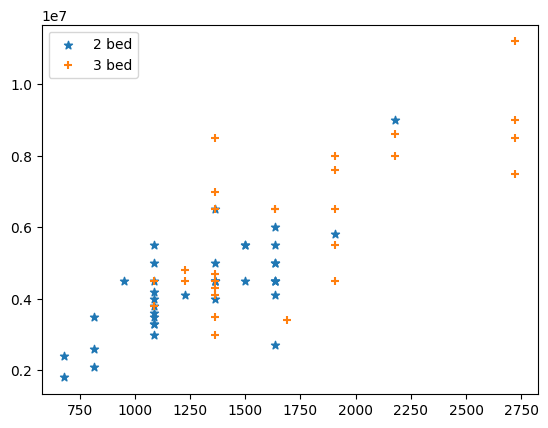

In [32]:
bed2 = df_10[(df_10["location"] == "Bhara kahu") & (df_10["bedrooms"] == 2)]
bed3 = df_10[(df_10["location"] == "Bhara kahu") & (df_10["bedrooms"] == 3)]

plt.scatter(bed2.Area_Sqrt_Feet, bed2.price, marker="*", label="2 bed")
plt.scatter(bed3.Area_Sqrt_Feet, bed3.price, marker="+", label="3 bed")
plt.legend()

{
    1 : {
        mean: np.mean(),
        std: np.std(),
        count: total no. of bed
    }
    2 : {
        mean: np.mean(),
        std: np.std(),
        count: total no. of bed
    }
}

We will remove the points if price of 2 bedroom appartment is less than 1 bedroom appartment.

In [33]:
def set_data(df):
    exclude_indeces = np.array([])
    for loc, location in df.groupby('location'):
        beds = {}
        for bed, bedroom in location.groupby('bedrooms'):
            beds[bed] = {
                "mean": np.mean(bedroom.Price_per_Square_Feet),
                "std": np.mean(bedroom.Price_per_Square_Feet),
                "count": bedroom.shape[0]
            }
        
        for bed, bedroom in location.groupby('bedrooms'):
            states = beds.get(bed-1)
            if states and states["count"] > 5:
                exclude_indeces = np.append(exclude_indeces, bedroom[bedroom.Price_per_Square_Feet < states["mean"]].index.values)
    
    return df.drop(exclude_indeces, axis="index")

In [34]:
df_11 = set_data(df_10)
df_11.shape

(24832, 8)

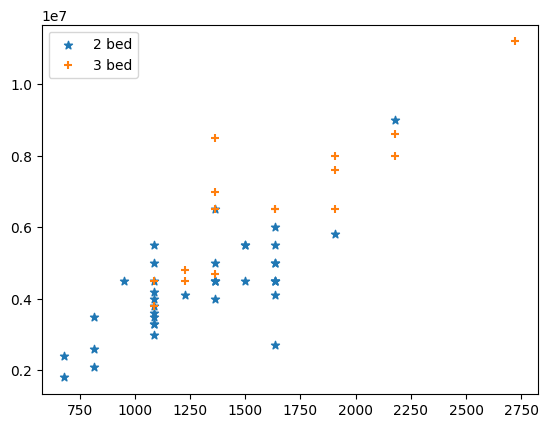

In [35]:
beds2 = df_11[(df_11.location == "Bhara kahu") & (df_11.bedrooms == 2)]
beds3 = df_11[(df_11.location == "Bhara kahu") & (df_11.bedrooms == 3)]
plt.scatter(beds2.Area_Sqrt_Feet, beds2.price, marker="*", label="2 bed")
plt.scatter(beds3.Area_Sqrt_Feet, beds3.price, marker="+", label="3 bed")
plt.legend()


<Axes: xlabel='Price_per_Square_Feet', ylabel='Count'>

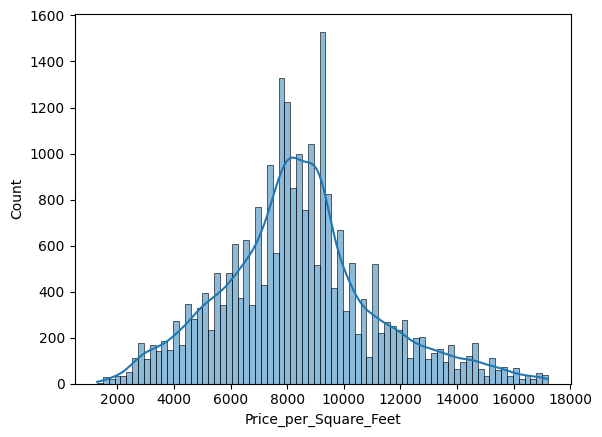

In [36]:
sns.histplot(df_11.Price_per_Square_Feet, kde=True)

(array([ 332.,    0., 3350.,    0., 9341.,    0., 6018.,    0., 4066.,
        1725.]),
 array([1. , 1.5, 2. , 2.5, 3. , 3.5, 4. , 4.5, 5. , 5.5, 6. ]),
 <BarContainer object of 10 artists>)

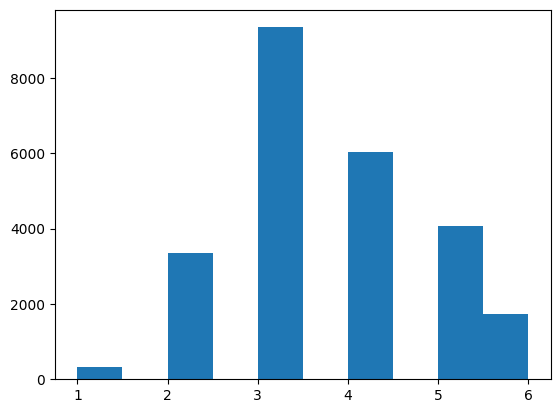

In [37]:
plt.hist(df_11.bedrooms)

(array([ 512., 2759.,    0., 6653.,    0., 6299., 4348.,    0., 3462.,
         799.]),
 array([1. , 1.6, 2.2, 2.8, 3.4, 4. , 4.6, 5.2, 5.8, 6.4, 7. ]),
 <BarContainer object of 10 artists>)

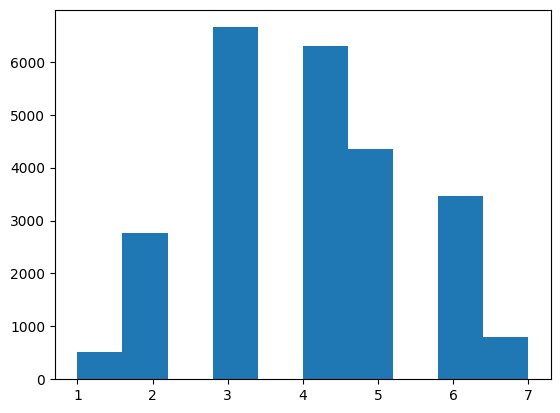

In [38]:
plt.hist(df_11.baths)

In [39]:
df_11[df_11.baths > df_11.bedrooms+2]

,city,location,Area_Sqrt_Feet,baths,bedrooms,price,Price_per_Square_Feet,Area_Sqrt_Feet_Zscore
604,Faisalabad,Samundari Road,1361.2550,6,3,7200000,5289.236770,-0.782619
734,Faisalabad,Others,1361.2550,7,4,9000000,6611.545963,-0.782619
754,Karachi,Scheme 33,1306.8048,7,4,11500000,8800.090113,-0.828706
1019,Faisalabad,Satiana Road,2178.0080,7,4,16000000,7346.162181,-0.091307
1347,Karachi,Korangi,1306.8048,7,4,16000000,12243.603635,-0.828706
...,...,...,...,...,...,...,...,...
51666,Lahore,DHA Defence,2722.5100,7,4,32500000,11937.513544,0.369567
52936,Lahore,DHA Defence,2722.5100,7,4,32500000,11937.513544,0.369567
56183,Lahore,Bahria Town,1361.2550,6,3,11000000,8080.778399,-0.782619
56518,Karachi,Gadap Town,1551.8307,7,4,16000000,10310.403061,-0.621313


In [40]:
df_12 = df_11[df_11["baths"] < df_11["bedrooms"]+2]
df_12.shape

(23383, 8)

In [41]:
df_12.drop(columns=["Price_per_Square_Feet", "Area_Sqrt_Feet_Zscore"], axis="columns" ,inplace=True)

C:\Users\hp\AppData\Local\Temp\ipykernel_16008\2915932420.py:1: SettingWithCopyWarning: 
A value is trying to be set on a copy of a slice from a DataFrame

See the caveats in the documentation: https://pandas.pydata.org/pandas-docs/stable/user_guide/indexing.html#returning-a-view-versus-a-copy
  df_12.drop(columns=["Price_per_Square_Feet", "Area_Sqrt_Feet_Zscore"], axis="columns" ,inplace=True)


In [42]:
df_12.head()

,city,location,Area_Sqrt_Feet,baths,bedrooms,price
2,Islamabad,DHA Defence,2178.0080,3,3,7000000
3,Islamabad,DHA Defence,2722.5100,3,3,19000000
9,Islamabad,Ghauri Town,1361.2550,3,2,4500000
17,Lahore,Military Accounts Housing Society,2178.0080,7,6,16500000
18,Lahore,Eden,2041.8825,4,4,13500000


In [43]:
city_dict = {}
location_list = []
for cities in df.city.unique():
    dataframe = df_12[df_12.city == cities]
    
    for loc in dataframe.location.unique():
        location_list.append(loc)
    
    city_dict[cities] = location_list
    location_list = []

print(city_dict)
    

{'Islamabad': ['DHA Defence', 'Ghauri Town', 'Bahria Town', 'Kuri Road', 'Chatha Bakhtawar', 'G-13', 'Bhara kahu', 'Lehtarar Road', 'PWD Housing Scheme', 'Burma Town', 'Others', 'Islamabad Highway', 'Bani Gala', 'G-10', 'Korang Town', 'G-15', 'D-17', 'I-10', 'FECHS', 'Pakistan Town', 'Shaheen Town', 'Ali Pur', 'F-17', 'H-13', 'Naval Anchorage', 'G-8', 'CBR Town', 'Zaraj Housing Scheme', 'Jhangi Syedan', 'G-11', 'I-14', 'Soan Garden', 'D-12', 'Alipur Farash', 'E-11', 'I-9', 'B-17', 'G-14', 'G-9', 'F-11', 'I-8', 'Green Avenue', 'National Police Foundation O-9', 'Gulberg', 'Garden Town', 'Madina Town'], 'Lahore': ['Military Accounts Housing Society', 'Eden', 'Askari', 'Gulberg', 'Others', 'Mateen Avenue', 'Paragon City', 'Bahria Town', 'Samanabad', 'Model Town', 'Canal Garden', 'Pak Arab Housing Society', 'DHA Defence', 'Cavalry Ground', 'Harbanspura Road', 'Ashiana-e-Quaid Housing Scheme', 'Iqbal Park', 'New Super Town', 'Valencia Housing Society', 'Mansoorah', 'Marghzar Officers Colony'

In [44]:
from sklearn.preprocessing import LabelEncoder

df_13 = df_12.copy()
encode = LabelEncoder()
df_13.city = encode.fit_transform(df_13.city)
df_13.location = encode.fit_transform(df_13.location)

In [45]:
df_13.head()

,city,location,Area_Sqrt_Feet,baths,bedrooms,price
2,1,59,2178.0080,3,3,7000000
3,1,59,2722.5100,3,3,19000000
9,1,93,1361.2550,3,2,4500000
17,3,161,2178.0080,7,6,16500000
18,3,69,2041.8825,4,4,13500000


In [46]:
df_13.describe()

,city,location,Area_Sqrt_Feet,baths,bedrooms,price
count,23383.000000,23383.000000,23383.000000,23383.000000,23383.000000,2.338300e+04
mean,2.572296,102.661378,1930.578961,3.881837,3.603943,1.657419e+07
std,0.976096,73.636032,856.710982,1.324847,1.165890,9.198647e+06
min,0.000000,0.000000,326.701200,1.000000,1.000000,1.200000e+06
25%,2.000000,30.000000,1361.255000,3.000000,3.000000,9.800000e+06
50%,3.000000,84.000000,1633.506000,4.000000,3.000000,1.450000e+07
75%,3.000000,182.000000,2722.510000,5.000000,4.000000,2.250000e+07
max,4.000000,247.000000,5445.020000,7.000000,6.000000,4.480000e+07


In [47]:
df_13["locate"] = df_12["location"]
df_13["city_2"] = df_12["city"]

In [48]:
df_13.head()

,city,location,Area_Sqrt_Feet,baths,bedrooms,price,locate,city_2
2,1,59,2178.0080,3,3,7000000,DHA Defence,Islamabad
3,1,59,2722.5100,3,3,19000000,DHA Defence,Islamabad
9,1,93,1361.2550,3,2,4500000,Ghauri Town,Islamabad
17,3,161,2178.0080,7,6,16500000,Military Accounts Housing Society,Lahore
18,3,69,2041.8825,4,4,13500000,Eden,Lahore


In [49]:
city = {}
location = {}

for key, value in zip(df_13.city_2, df_13.city):
    city[key] = value
    
for key, value in zip(df_13.locate, df_13.location):
    location[key] = value

In [50]:
city

{'Islamabad': 1, 'Lahore': 3, 'Faisalabad': 0, 'Rawalpindi': 4, 'Karachi': 2}

In [51]:
location

{'DHA Defence': 59,
 'Ghauri Town': 93,
 'Military Accounts Housing Society': 161,
 'Eden': 69,
 'Askari': 19,
 'Gulberg': 103,
 'Others': 188,
 'Mateen Avenue': 158,
 'Muslim Town': 167,
 'Bahria Town Rawalpindi': 30,
 'Gulshan Abad': 108,
 'Shalley Valley': 227,
 'Malir': 152,
 'Gulshan-e-Iqbal Town': 109,
 'Shahra-e-Faisal': 225,
 'Bahria Town': 28,
 'Paragon City': 194,
 'Samanabad': 211,
 'Westridge': 244,
 'Bahria Town Karachi': 29,
 'Kuri Road': 140,
 'Chatha Bakhtawar': 51,
 'Model Town': 164,
 'Canal Garden': 42,
 'Pak Arab Housing Society': 192,
 'Northern Bypass': 184,
 'Fazaia Housing Scheme': 78,
 'G-13': 84,
 'Cavalry Ground': 46,
 'Harbanspura Road': 116,
 'Ashiana-e-Quaid Housing Scheme': 18,
 'Askari 14': 20,
 'Sadiqabad': 209,
 'Bhara kahu': 34,
 'Iqbal Park': 124,
 'Scheme 33': 218,
 'Lehtarar Road': 148,
 'Misryal Road': 163,
 'New Super Town': 178,
 'Ghulam Mohammad Abad': 96,
 'Valencia Housing Society': 239,
 'Mansoorah': 155,
 'Marghzar Officers Colony': 157,
 '

In [52]:
X = df_13.drop(columns=["price", "locate", "city_2"], axis="columns")
y = df_13.price

In [53]:
X.head()

,city,location,Area_Sqrt_Feet,baths,bedrooms
2,1,59,2178.0080,3,3
3,1,59,2722.5100,3,3
9,1,93,1361.2550,3,2
17,3,161,2178.0080,7,6
18,3,69,2041.8825,4,4


In [54]:
y.head()

2      7000000
3     19000000
9      4500000
17    16500000
18    13500000
Name: price, dtype: int64

In [55]:
X_train, X_test, y_train, y_test = train_test_split(X, y, test_size=0.2, random_state=20)

In [56]:
lin = LinearRegression()
lin.fit(X_train, y_train)
lin.score(X_test, y_test)

0.710598631331139

# ShuffleSplit ---> Randomly Shuffle 5 times our X_train.

In [57]:
shuffle = ShuffleSplit(n_splits=5, test_size=0.2, random_state=0)
cross_val_score(LinearRegression(), X_train, y_train, cv=shuffle)

array([0.70925215, 0.73028116, 0.72491997, 0.71558533, 0.71757062])

In [ ]:
models = {
    "linear": {
        "model": LinearRegression(),
        "param": {}
    },
    
    "lasso": {
        "model": Lasso(),
        "param": {
            "alpha": [1, 3, 5],
            "selection": ["cyclic", "random"]
        }
    },
    
    "decision": {
        "model": DecisionTreeRegressor(),
        "param": {
            "criterion": ['squared_error', 'friedman_mse'],
            "splitter": ['best', 'random']
        }
    },
    
    "random": {
        "model": RandomForestRegressor(),
        "param": {
            "n_estimators": [10, 50, 100],
            "criterion": ['squared_error', 'absolute_error']
        }
    }
}

shuffle = ShuffleSplit(n_splits=5, test_size=0.2, random_state=0)
scores = []

for i, j in models.items():
    grid = GridSearchCV(estimator=j["model"], param_grid=j["param"], return_train_score=False, cv=shuffle)
    grid.fit(X_train, y_train)
    scores.append({
        "model": i,
        "best_param": grid.best_params_,
        "best_score": grid.best_score_
    })

In [60]:
scores

[{'model': 'linear',
  'best_param': {},
  'best_score': np.float64(0.7195218459298253)},
 {'model': 'lasso',
  'best_param': {'alpha': 3, 'selection': 'cyclic'},
  'best_score': np.float64(0.7195218510341203)},
 {'model': 'decision',
  'best_param': {'criterion': 'squared_error', 'splitter': 'best'},
  'best_score': np.float64(0.8772224192098943)},
 {'model': 'random',
  'best_param': {'criterion': 'squared_error', 'n_estimators': 100},
  'best_score': np.float64(0.9029461125161877)}]

In [61]:
data = []
a = []
for i in scores:
    for keys, values in i.items():
        a.append(values)
    
    data.append(a)
    a = []

print(data)

[['linear', {}, np.float64(0.7195218459298253)], ['lasso', {'alpha': 3, 'selection': 'cyclic'}, np.float64(0.7195218510341203)], ['decision', {'criterion': 'squared_error', 'splitter': 'best'}, np.float64(0.8772224192098943)], ['random', {'criterion': 'squared_error', 'n_estimators': 100}, np.float64(0.9029461125161877)]]


In [62]:
pd.DataFrame(data=data, columns=["Model", "Best Param", "Best Score"])

,Model,Best Param,Best Score
0,linear,{},0.719522
1,lasso,"{'alpha': 3, 'selection': 'cyclic'}",0.719522
2,decision,"{'criterion': 'squared_error', 'splitter': 'be...",0.877222
3,random,"{'criterion': 'squared_error', 'n_estimators':...",0.902946


In [63]:
random = RandomForestRegressor(n_estimators=100, criterion="squared_error")
my_model = random.fit(X_train, y_train)

In [64]:
random.predict(X_test)

array([14853667.91721724, 17663993.81791331,  9498503.2051282 , ...,
       32237833.33333333, 15964242.02512817,  5613775.        ],
      shape=(4677,))

In [65]:
random.score(X_test, y_test)

0.9049625096237328

In [66]:
import pickle
with open("MyLinearModel", "wb") as f:
    pickle.dump(my_model, f)

In [67]:
with open("MyLinearModel" , 'rb') as f:
    load_file = pickle.load(f)

In [68]:
load_file.predict(X_test)

array([14853667.91721724, 17663993.81791331,  9498503.2051282 , ...,
       32237833.33333333, 15964242.02512817,  5613775.        ],
      shape=(4677,))

In [69]:
cl = {
    "city": city,
    "location": location
}

In [70]:
import json
with open("city_location.json", "a") as file:
    json.dump(cl, file) 

In [74]:
with open("city_location.json", "r") as file:
    data = json.load(file) 

In [75]:
data

{'city': {'Islamabad': 1,
  'Lahore': 3,
  'Faisalabad': 0,
  'Rawalpindi': 4,
  'Karachi': 2},
 'location': {'DHA Defence': 59,
  'Ghauri Town': 93,
  'Military Accounts Housing Society': 161,
  'Eden': 69,
  'Askari': 19,
  'Gulberg': 103,
  'other': 248,
  'Mateen Avenue': 158,
  'Muslim Town': 167,
  'Bahria Town Rawalpindi': 30,
  'Gulshan Abad': 108,
  'Shalley Valley': 227,
  'Malir': 152,
  'Gulshan-e-Iqbal Town': 109,
  'Shahra-e-Faisal': 225,
  'Bahria Town': 28,
  'Paragon City': 194,
  'Samanabad': 211,
  'Westridge': 244,
  'Bahria Town Karachi': 29,
  'Kuri Road': 140,
  'Chatha Bakhtawar': 51,
  'Model Town': 164,
  'Canal Garden': 42,
  'Pak Arab Housing Society': 192,
  'Northern Bypass': 184,
  'Fazaia Housing Scheme': 78,
  'G-13': 84,
  'Cavalry Ground': 46,
  'Harbanspura Road': 116,
  'Ashiana-e-Quaid Housing Scheme': 18,
  'Askari 14': 20,
  'Sadiqabad': 209,
  'Bhara kahu': 34,
  'Iqbal Park': 124,
  'Scheme 33': 218,
  'Lehtarar Road': 148,
  'Misryal Road': 16

In [76]:
with open("location.json", "w") as file:
    json.dump(city_dict, file) 

In [ ]:
load_file.predict([[2, 3,]])